In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path
from urllib.parse import quote_plus

import pandas as pd

from dotenv import load_dotenv
from sqlalchemy import create_engine


_NOTEBOOK_DIR = Path.cwd()
_PROJECT_ROOT = _NOTEBOOK_DIR
for _ in range(5):
    if (_PROJECT_ROOT / ".env").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent

# Repo Models/Training on path (works whether kernel cwd is project root or Training/)
_TRAINING_DIR = _PROJECT_ROOT / "Models" / "Training"
sys.path.insert(0, str(_TRAINING_DIR))

def _load_env():
    load_dotenv(_PROJECT_ROOT / ".env")

def _db_url():
    host = os.getenv("PGHOST") or os.getenv("DB_HOST", "localhost")
    port = os.getenv("PGPORT") or os.getenv("DB_PORT", "5432")
    user = os.getenv("PGUSER") or os.getenv("DB_USER", "postgres")
    password = os.getenv("PGPASSWORD") or os.getenv("DB_PASS", "")
    dbname = os.getenv("PGDATABASE") or os.getenv("DB_NAME", "baseball")
    pw = quote_plus(password) if password else ""
    return f"postgresql://{user}:{pw}@{host}:{port}/{dbname}"

_load_env()
engine = create_engine(_db_url())

In [2]:
from sklearn.metrics import log_loss, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
import optuna
import xgboost as xgb

from data_prep_batters import (
    load_and_prepare_batter,
    PITCH_RESULT_CLASSES,
    RESULT_TO_IDX,
    IDX_TO_RESULT,
    BUCKET_CLASS_NAMES,
    NUM_BUCKET_CLASSES,
    IMMEDIATE_PITCH_RESULT_CLASSES,
    IMMEDIATE_RESULT_TO_IDX,
    IMMEDIATE_PLUS_HIT_CLASSES,
    IMMEDIATE_PLUS_HIT_RESULT_TO_IDX,
)

print("Imports OK.")

Imports OK.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Option A: 4-class immediate (ball, called_strike, swinging_strike, foul). Option B: 5-class + hit bucket (hit = successful hits: 1b, 2b, 3b, hr).
use_immediate_outcomes_only = False   # 4 classes; set False if using 5-class below
use_immediate_plus_hit = True       # 5 classes: ball, called_strike, swinging_strike, foul, hit (successful hits only; in_play_out and HBP excluded)

X_train, y_train, X_val, y_val, X_test, y_test, cat_encodings, feature_cols = load_and_prepare_batter(
    engine, time_based=True, train_frac=0.7, val_frac=0.15, random_state=42,
    use_pitch_result_target=True,
    use_immediate_outcomes_only=use_immediate_outcomes_only and not use_immediate_plus_hit,
    use_immediate_plus_hit=use_immediate_plus_hit,
)

# Per-pitch target: 4-class immediate, 5-class immediate+hit, 5-bucket at-bat, or full 11-class pitch_result
if use_immediate_plus_hit:
    CLASS_NAMES = IMMEDIATE_PLUS_HIT_CLASSES
    num_class = len(IMMEDIATE_PLUS_HIT_CLASSES)
    y_train_idx = y_train.map(lambda r: IMMEDIATE_PLUS_HIT_RESULT_TO_IDX.get(r, 0)).astype(int)
    y_val_idx = y_val.map(lambda r: IMMEDIATE_PLUS_HIT_RESULT_TO_IDX.get(r, 0)).astype(int)
    y_test_idx = y_test.map(lambda r: IMMEDIATE_PLUS_HIT_RESULT_TO_IDX.get(r, 0)).astype(int)
elif use_immediate_outcomes_only:
    CLASS_NAMES = IMMEDIATE_PITCH_RESULT_CLASSES
    num_class = len(IMMEDIATE_PITCH_RESULT_CLASSES)
    y_train_idx = y_train.map(lambda r: IMMEDIATE_RESULT_TO_IDX.get(r, 0)).astype(int)
    y_val_idx = y_val.map(lambda r: IMMEDIATE_RESULT_TO_IDX.get(r, 0)).astype(int)
    y_test_idx = y_test.map(lambda r: IMMEDIATE_RESULT_TO_IDX.get(r, 0)).astype(int)
else:
    use_buckets = np.issubdtype(y_train.dtype, np.integer) and set(np.unique(y_train)).issubset({0, 1, 2, 3, 4})
    if use_buckets:
        CLASS_NAMES = BUCKET_CLASS_NAMES
        num_class = NUM_BUCKET_CLASSES
        y_train_idx = y_train.astype(int)
        y_val_idx = y_val.astype(int)
        y_test_idx = y_test.astype(int)
    else:
        CLASS_NAMES = PITCH_RESULT_CLASSES
        num_class = len(PITCH_RESULT_CLASSES)
        y_train_idx = y_train.map(lambda r: RESULT_TO_IDX.get(r, 0)).astype(int)
        y_val_idx = y_val.map(lambda r: RESULT_TO_IDX.get(r, 0)).astype(int)
        y_test_idx = y_test.map(lambda r: RESULT_TO_IDX.get(r, 0)).astype(int)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Features: {feature_cols}")
print(f"Target: {'immediate+hit (5 classes)' if use_immediate_plus_hit else 'immediate outcomes (4 classes)' if use_immediate_outcomes_only else '5-bucket (at-bat outcome)' if not use_immediate_outcomes_only and np.issubdtype(y_train.dtype, np.integer) and set(np.unique(y_train)).issubset({0,1,2,3,4}) else 'per-pitch pitch_result'}, n_classes={num_class}")
print("\nTarget distribution (train):")
print(y_train.value_counts())

Train: 628442 | Val: 617880 | Test: 621033
Features: ['pitch_type', 'plate_x', 'plate_z', 'release_speed', 'release_spin_rate', 'hb_in', 'ivb_in', 'spin_axis', 'spin_axis_x_pthrows', 'balls', 'strikes', 'stand', 'p_throws', 'batter', 'career_AB', 'career_H', 'career_HR', 'career_BA', 'career_OBP', 'career_SLG', 'home_team', 'inning', 'outs_when_up', 'is_pitcher_count', 'is_batter_count', 'pitcher', 'previous_pitch_type', 'previous_was_strike', 'in_zone', 'is_fastball', 'game_year', 'previous_2_pitch_type', 'previous_2_was_strike', 'previous_3_pitch_type', 'previous_3_was_strike']
Target: immediate+hit (5 classes), n_classes=5

Target distribution (train):
pitch_result
ball               255006
foul               135358
called_strike      117231
swinging_strike     80277
hit                 40570
Name: count, dtype: int64


In [4]:
# Train on full data; use per-class weights to correct imbalance (foul over-predicted, swinging_strike under-predicted).
X_train_bal = X_train
y_train_idx_bal = y_train_idx
if use_immediate_plus_hit:
    # 5-class immediate+hit: down-weight foul (0.4), up-weight hit (2.0) and swinging_strike (2.0); ball=1.3, called_strike=1.8.
    WEAK_CLASS_NAMES = ["swinging_strike"]
    weak_class_indices = np.array([CLASS_NAMES.index(c) for c in WEAK_CLASS_NAMES if c in CLASS_NAMES])
    class_weights = np.ones(num_class)
    class_weights[weak_class_indices] = 2.0
    foul_idx = CLASS_NAMES.index("foul") if "foul" in CLASS_NAMES else None
    if foul_idx is not None:
        class_weights[foul_idx] = 0.4
    strike_idx = CLASS_NAMES.index("called_strike") if "called_strike" in CLASS_NAMES else None
    if strike_idx is not None:
        class_weights[strike_idx] = 1.8
    ball_idx = CLASS_NAMES.index("ball") if "ball" in CLASS_NAMES else None
    if ball_idx is not None:
        class_weights[ball_idx] = 1.3
    hit_idx_w = CLASS_NAMES.index("hit") if "hit" in CLASS_NAMES else None
    if hit_idx_w is not None:
        class_weights[hit_idx_w] = 2.0
    # Undersample foul for 5-class too: keep 35% of foul samples.
    if foul_idx is not None:
        rng = np.random.RandomState(42)
        y_flat = y_train_idx_bal.to_numpy().ravel()
        foul_positions = np.where(y_flat == foul_idx)[0]
        n_foul_keep = int(len(foul_positions) * 0.35)
        kept_foul_positions = rng.choice(foul_positions, size=n_foul_keep, replace=False)
        keep_mask = np.ones(len(y_flat), dtype=bool)
        keep_mask[foul_positions] = False
        keep_mask[kept_foul_positions] = True
        X_train_bal = X_train_bal.iloc[keep_mask].copy()
        y_train_idx_bal = y_train_idx_bal.iloc[keep_mask].copy()



elif use_immediate_outcomes_only:
    # Immediate 4-class: down-weight foul; up-weight swinging_strike; ball, called_strike.
    WEAK_CLASS_NAMES = ["swinging_strike"]
    weak_class_indices = np.array([CLASS_NAMES.index(c) for c in WEAK_CLASS_NAMES if c in CLASS_NAMES])
    class_weights = np.ones(num_class)
    class_weights[weak_class_indices] = 2.0
    foul_idx = CLASS_NAMES.index("foul") if "foul" in CLASS_NAMES else None
    if foul_idx is not None:
        class_weights[foul_idx] = 0.4
    strike_idx = CLASS_NAMES.index("called_strike") if "called_strike" in CLASS_NAMES else None
    if strike_idx is not None:
        class_weights[strike_idx] = 1.8
    ball_idx = CLASS_NAMES.index("ball") if "ball" in CLASS_NAMES else None
    if ball_idx is not None:
        class_weights[ball_idx] = 1.3
    # Undersample foul: keep 35% of foul samples.
    if foul_idx is not None:
        rng = np.random.RandomState(42)
        y_flat = y_train_idx_bal.to_numpy().ravel()
        foul_positions = np.where(y_flat == foul_idx)[0]
        n_foul_keep = int(len(foul_positions) * 0.35)
        kept_foul_positions = rng.choice(foul_positions, size=n_foul_keep, replace=False)
        keep_mask = np.ones(len(y_flat), dtype=bool)
        keep_mask[foul_positions] = False
        keep_mask[kept_foul_positions] = True
        X_train_bal = X_train_bal.iloc[keep_mask].copy()
        y_train_idx_bal = y_train_idx_bal.iloc[keep_mask].copy()

elif num_class == 5 and not use_immediate_plus_hit:
    # 5-bucket at-bat: weak = single (3), extra_base (4)
    WEAK_CLASS_NAMES = ["single", "extra_base"]
    weak_class_indices = np.array([CLASS_NAMES.index(c) for c in WEAK_CLASS_NAMES])
    TARGETED_WEIGHT_WEAK = 1.5
    class_weights = np.ones(num_class)
    class_weights[weak_class_indices] = TARGETED_WEIGHT_WEAK
else:
    WEAK_CLASS_NAMES = ["swinging_strike", "foul_tip", "in_play_out", "in_play_1b", "in_play_2b", "in_play_3b", "in_play_hr"]
    weak_class_indices = np.array([CLASS_NAMES.index(c) for c in WEAK_CLASS_NAMES])
    TARGETED_WEIGHT_WEAK = 1.5
    class_weights = np.ones(num_class)
    class_weights[weak_class_indices] = TARGETED_WEIGHT_WEAK
sample_weight_batter = class_weights[y_train_idx_bal.to_numpy().ravel()]
if use_immediate_plus_hit:
    print(f"Train: n={len(X_train_bal)} (5-class: ball, called_strike, swinging_strike, foul, hit) with class weights: ball=1.3, called_strike=1.8, swinging_strike=2, foul=0.4, hit=2.0")
elif use_immediate_outcomes_only:
    print(f"Train: n={len(X_train_bal)} (foul undersampled to 35%) with class weights: ball=1.3, called_strike=1.8, swinging_strike=2, foul=0.4")
else:
    print(f"Train: n={len(X_train)} with targeted weights (weak classes {TARGETED_WEIGHT_WEAK}x)")

Train: n=540459 (5-class: ball, called_strike, swinging_strike, foul, hit) with class weights: ball=1.3, called_strike=1.8, swinging_strike=2, foul=0.4, hit=2.0


In [5]:
# Hyperparameter tuning: Optuna minimizes 0.5*log_loss + 0.3*(1 - macro F1) + 0.2*dist_gap.
# dist_gap = MSE between predicted and actual class proportions (punishes foul over-prediction).
def tune_batter_pitch_result(trial):
    n_estimators = trial.suggest_int("n_estimators", 15, 500)
    max_depth = trial.suggest_int("max_depth", 3, 12)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    reg_alpha = trial.suggest_float("reg_alpha", 0.1, 10.0)
    reg_lambda = trial.suggest_float("reg_lambda", 0.1, 10.0)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    model = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=num_class,
        random_state=42,
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        min_child_weight=min_child_weight,
    )
    model.fit(
        X_train_bal[feature_cols],
        y_train_idx_bal,
        sample_weight=sample_weight_batter,
    )
    proba = model.predict_proba(X_val[feature_cols])
    pred = np.argmax(proba, axis=1)
    macro_f1 = f1_score(y_val_idx, pred, average="macro", zero_division=0)
    logls = log_loss(y_val_idx, proba, labels=np.arange(num_class))
    # Distribution penalty: punish deviation of predicted class proportions from actual (MSE).
    pred_props = pd.Series(pred).value_counts(normalize=True).reindex(np.arange(num_class)).fillna(0).values
    actual_props = pd.Series(y_val_idx).value_counts(normalize=True).reindex(np.arange(num_class)).fillna(0).values
    dist_gap = np.sum((pred_props - actual_props) ** 2)
    # Foul over-prediction penalty: massive penalty if predicted foul rate exceeds actual by >2%.
    foul_idx_obj = CLASS_NAMES.index("foul") if "foul" in CLASS_NAMES else None
    foul_penalty = 0.0
    if foul_idx_obj is not None:
        actual_foul_rate = np.mean(np.asarray(y_val_idx).ravel() == foul_idx_obj)
        pred_foul_rate = np.mean(pred == foul_idx_obj)
        if pred_foul_rate > (actual_foul_rate + 0.02):
            foul_penalty = (pred_foul_rate - actual_foul_rate) * 5.0
    # Hit under-prediction penalty (5-class): penalize if predicted hit rate is below actual by >1%.
    hit_idx_obj = CLASS_NAMES.index("hit") if "hit" in CLASS_NAMES else None
    hit_penalty = 0.0
    if hit_idx_obj is not None:
        actual_hit_rate = np.mean(np.asarray(y_val_idx).ravel() == hit_idx_obj)
        pred_hit_rate = np.mean(pred == hit_idx_obj)
        if pred_hit_rate < (actual_hit_rate - 0.01):
            hit_penalty = (actual_hit_rate - pred_hit_rate) * 5.0
    return 0.5 * logls + 0.3 * (1.0 - macro_f1) + 0.2 * dist_gap + foul_penalty + hit_penalty

study_batter = optuna.create_study(direction="minimize")
study_batter.optimize(tune_batter_pitch_result, n_trials=25)
print("Best blended (val):", study_batter.best_value, "| Best params:", study_batter.best_params)

[I 2026-04-23 03:14:20,986] A new study created in memory with name: no-name-27eea439-deaa-46cc-a779-e51468d1709b
[I 2026-04-23 03:14:41,682] Trial 0 finished with value: 0.7893190000217245 and parameters: {'n_estimators': 180, 'max_depth': 11, 'learning_rate': 0.12006977375201579, 'subsample': 0.9435978301484353, 'colsample_bytree': 0.9893497467730819, 'reg_alpha': 2.7109798222485, 'reg_lambda': 2.330512169331467, 'min_child_weight': 9}. Best is trial 0 with value: 0.7893190000217245.
[I 2026-04-23 03:14:51,241] Trial 1 finished with value: 0.8108875823354987 and parameters: {'n_estimators': 231, 'max_depth': 5, 'learning_rate': 0.1106753668142831, 'subsample': 0.8656856357282032, 'colsample_bytree': 0.5246163879080141, 'reg_alpha': 9.1402269750071, 'reg_lambda': 0.6097986331226701, 'min_child_weight': 5}. Best is trial 0 with value: 0.7893190000217245.
[I 2026-04-23 03:15:13,501] Trial 2 finished with value: 0.791465510645668 and parameters: {'n_estimators': 373, 'max_depth': 8, 'lea

Best blended (val): 0.7759808809894198 | Best params: {'n_estimators': 388, 'max_depth': 12, 'learning_rate': 0.1585714152714994, 'subsample': 0.9027485841100316, 'colsample_bytree': 0.9324107726105185, 'reg_alpha': 1.106575496718932, 'reg_lambda': 9.323135251454495, 'min_child_weight': 6}


In [6]:
# XGBoost multiclass classifier for pitch_result (hyperparameters from Optuna)
clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=num_class,
    random_state=42,
    **study_batter.best_params,
)
clf.fit(
    X_train_bal[feature_cols],
    y_train_idx_bal,
    sample_weight=sample_weight_batter,
    eval_set=[(X_val[feature_cols], y_val_idx)],
    verbose=20,
)

[0]	validation_0-mlogloss:1.68610
[20]	validation_0-mlogloss:1.27465
[40]	validation_0-mlogloss:1.22856
[60]	validation_0-mlogloss:1.21436
[80]	validation_0-mlogloss:1.20671
[100]	validation_0-mlogloss:1.20190
[120]	validation_0-mlogloss:1.19732
[140]	validation_0-mlogloss:1.19315
[160]	validation_0-mlogloss:1.19002
[180]	validation_0-mlogloss:1.18731
[200]	validation_0-mlogloss:1.18417
[220]	validation_0-mlogloss:1.18172
[240]	validation_0-mlogloss:1.17998
[260]	validation_0-mlogloss:1.17811
[280]	validation_0-mlogloss:1.17644
[300]	validation_0-mlogloss:1.17499
[320]	validation_0-mlogloss:1.17354
[340]	validation_0-mlogloss:1.17250
[360]	validation_0-mlogloss:1.17176
[380]	validation_0-mlogloss:1.17116
[387]	validation_0-mlogloss:1.17110


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9324107726105185
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [7]:
# Calibrate probabilities (isotonic on validation set) for run expectancy / sampling
from sklearn.calibration import CalibratedClassifierCV

# Calibrate on val without re-fitting clf (sklearn dropped cv=prefit; use FrozenEstimator).
try:
    from sklearn.frozen import FrozenEstimator
    clf_calibrated = CalibratedClassifierCV(FrozenEstimator(clf), method="isotonic")
except ImportError:
    clf_calibrated = CalibratedClassifierCV(clf, method="isotonic", cv="prefit")

clf_calibrated.fit(X_val[feature_cols], y_val_idx)
print("Calibrated classifier fitted on validation set (use for predict_proba)")

# Tune thresholds for weak classes: extended grid (lower T) then per-class thresholds.
def predict_with_weak_threshold(proba, threshold, weak_indices):
    pred = np.argmax(proba, axis=1)
    weak_proba = proba[:, weak_indices]
    weak_argmax_idx = np.argmax(weak_proba, axis=1)
    weak_max = np.max(weak_proba, axis=1)
    for i in range(len(pred)):
        if weak_max[i] >= threshold and weak_max[i] >= proba[i, pred[i]]:
            pred[i] = weak_indices[weak_argmax_idx[i]]
    return pred

def predict_with_per_class_threshold(proba, threshold_per_class, weak_indices):
    """threshold_per_class: list of length len(weak_indices), one T per weak class."""
    pred = np.argmax(proba, axis=1)
    weak_indices = np.asarray(weak_indices)
    threshold_per_class = np.asarray(threshold_per_class)
    for i in range(len(pred)):
        best_weak_k, best_weak_p = -1, -1.0
        for j, k in enumerate(weak_indices):
            if proba[i, k] >= threshold_per_class[j] and proba[i, k] > best_weak_p:
                best_weak_p = proba[i, k]
                best_weak_k = k
        if best_weak_k >= 0 and best_weak_p >= proba[i, pred[i]]:
            pred[i] = best_weak_k
    return pred

val_proba = clf_calibrated.predict_proba(X_val[feature_cols])
# 1) Single global T with extended grid (include 0.02, 0.03, 0.04 for rarer classes)
grid_single = [0.02, 0.03, 0.04, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
best_f1, threshold_weak = 0.0, 0.10
for T in grid_single:
    y_val_pred = predict_with_weak_threshold(val_proba, T, weak_class_indices)
    f1 = f1_score(y_val_idx, y_val_pred, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1, threshold_weak = f1, T
print(f"Single threshold (val): best macro F1 = {best_f1:.4f} at threshold_weak = {threshold_weak}")

# 2) Per-class thresholds: iterative tuning (one class at a time)
grid_per_class = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
threshold_per_weak_class = [threshold_weak] * len(weak_class_indices)
for j in range(len(weak_class_indices)):
    best_f1_j, best_t_j = 0.0, threshold_per_weak_class[j]
    for T in grid_per_class:
        threshold_per_weak_class[j] = T
        y_val_pred = predict_with_per_class_threshold(val_proba, threshold_per_weak_class, weak_class_indices)
        f1 = f1_score(y_val_idx, y_val_pred, average="macro", zero_division=0)
        if f1 > best_f1_j:
            best_f1_j, best_t_j = f1, T
    threshold_per_weak_class[j] = best_t_j
y_val_final = predict_with_per_class_threshold(val_proba, threshold_per_weak_class, weak_class_indices)
f1_per_class = f1_score(y_val_idx, y_val_final, average="macro", zero_division=0)
print(f"Per-class thresholds (val): macro F1 = {f1_per_class:.4f}")
print("Per-class T:", dict(zip(WEAK_CLASS_NAMES, threshold_per_weak_class)))

Calibrated classifier fitted on validation set (use for predict_proba)
Single threshold (val): best macro F1 = 0.4329 at threshold_weak = 0.02
Per-class thresholds (val): macro F1 = 0.4329
Per-class T: {'swinging_strike': 0.02}


In [8]:
import json
import joblib
import shutil

_SAVED = Path(_NOTEBOOK_DIR) / "saved_models"
_SAVED.mkdir(parents=True, exist_ok=True)

clf.save_model(str(_SAVED / "batter_pitch_result.json"))
print("Saved batter_pitch_result.json")

# Calibrated model for probability outputs (run expectancy / sampling)
joblib.dump(clf_calibrated, _SAVED / "batter_pitch_result_calibrated.joblib")
print("Saved batter_pitch_result_calibrated.joblib")

# Encoders for inference (same column order and mappings); per-class thresholds for weak-class recall
_result_to_idx = {CLASS_NAMES[i]: i for i in range(num_class)}
_idx_to_result = {str(i): CLASS_NAMES[i] for i in range(num_class)}
batter_encoders = {
    "feats_batter": feature_cols,
    "result_to_idx": _result_to_idx,
    "idx_to_result": _idx_to_result,
    "cat_encodings": cat_encodings,
    "pitch_result_classes": list(CLASS_NAMES),
    "threshold_weak": float(np.mean(threshold_per_weak_class)),
    "weak_class_indices": weak_class_indices.tolist(),
    "threshold_per_weak_class": [float(t) for t in threshold_per_weak_class],
}
with open(_SAVED / "batter_encoders.json", "w") as f:
    json.dump(batter_encoders, f, indent=2)
print("Saved batter_encoders.json")

# Copy to Models/saved_models so web app and evaluation can load
_MODELS = _PROJECT_ROOT / "Models" / "saved_models"
_MODELS.mkdir(parents=True, exist_ok=True)
shutil.copy(_SAVED / "batter_pitch_result.json", _MODELS / "batter_pitch_result.json")
shutil.copy(_SAVED / "batter_encoders.json", _MODELS / "batter_encoders.json")
if (_SAVED / "batter_pitch_result_calibrated.joblib").exists():
    shutil.copy(_SAVED / "batter_pitch_result_calibrated.joblib", _MODELS / "batter_pitch_result_calibrated.joblib")
print("Copied to Models/saved_models")

Saved batter_pitch_result.json
Saved batter_pitch_result_calibrated.joblib
Saved batter_encoders.json
Copied to Models/saved_models


Test accuracy: 0.6382
Test log-loss: 0.9131


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Log-loss vs logistic baseline: baseline=1.4467, model=0.9131 (36.9% relative reduction)
Test multiclass Brier: 0.4807 (train-freq baseline: 0.7329)
Test ECE top-1 (15 bins): 0.0130
Test ECE macro-marginal per class (15 bins): 0.0077
  ECE marginal ball: 0.0097
  ECE marginal called_strike: 0.0050
  ECE marginal swinging_strike: 0.0056
  ECE marginal foul: 0.0151
  ECE marginal hit: 0.0032
Log-loss vs train-frequency baseline: baseline=1.4477, model=0.9131 (36.9% relative reduction)
Val ECE top-1 (isotonic fit on val): 0.0146 — report test metrics above


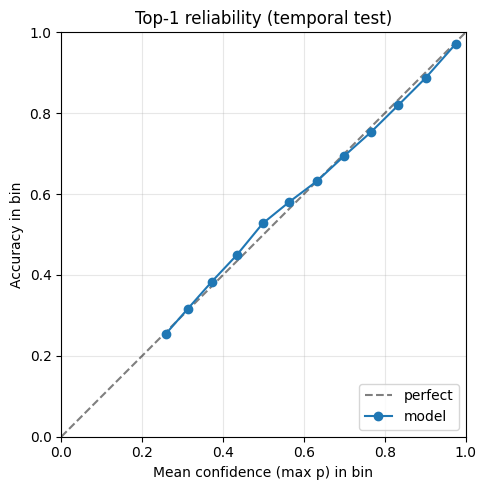

In [10]:
# Phase 4.1: Test accuracy, log-loss, multiclass Brier, ECE (15 bins), freq baseline, reliability plot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from batter_calibration import plot_top1_reliability, summarize_calibration

y_pred = clf_calibrated.predict(X_test[feature_cols])
y_proba = clf_calibrated.predict_proba(X_test[feature_cols])
_labels = np.arange(num_class)
acc = accuracy_score(y_test_idx, y_pred)
ll = log_loss(y_test_idx, y_proba, labels=_labels)
print(f"Test accuracy: {acc:.4f}")
print(f"Test log-loss: {ll:.4f}")

# Logistic baseline (same features): compare test log-loss against calibrated XGBoost
logreg = LogisticRegression(max_iter=1200, solver="lbfgs")
logreg.fit(X_train[feature_cols], y_train_idx)
logreg_proba_test = logreg.predict_proba(X_test[feature_cols])
ll_logreg = log_loss(y_test_idx, logreg_proba_test, labels=_labels)
ll_gain_vs_logreg = 100.0 * ((ll_logreg - ll) / ll_logreg) if ll_logreg > 0 else 0.0
print(
    f"Log-loss vs logistic baseline: baseline={ll_logreg:.4f}, model={ll:.4f} "
    f"({ll_gain_vs_logreg:.1f}% relative reduction)"
)

summ = summarize_calibration(
    np.asarray(y_test_idx).ravel(),
    y_proba,
    np.asarray(y_train_idx).ravel(),
    class_names=list(CLASS_NAMES),
    n_bins=15,
    labels=_labels,
)
print(f"Test multiclass Brier: {summ['multiclass_brier']:.4f} (train-freq baseline: {summ['multiclass_brier_freq_baseline']:.4f})")
print(f"Test ECE top-1 (15 bins): {summ['ece_top1']:.4f}")
print(f"Test ECE macro-marginal per class (15 bins): {summ['ece_macro_marginal']:.4f}")
for name, v in summ.get("ece_per_class_by_name", {}).items():
    print(f"  ECE marginal {name}: {v:.4f}")
pct = 100.0 * summ["log_loss_rel_improvement"]
print(
    f"Log-loss vs train-frequency baseline: baseline={summ['log_loss_freq_baseline']:.4f}, "
    f"model={summ['log_loss_model']:.4f} ({pct:.1f}% relative reduction)"
)

val_proba_diag = clf_calibrated.predict_proba(X_val[feature_cols])
summ_val = summarize_calibration(
    np.asarray(y_val_idx).ravel(),
    val_proba_diag,
    np.asarray(y_train_idx).ravel(),
    class_names=list(CLASS_NAMES),
    n_bins=15,
    labels=_labels,
)
print(f"Val ECE top-1 (isotonic fit on val): {summ_val['ece_top1']:.4f} — report test metrics above")

plot_top1_reliability(
    np.asarray(y_test_idx).ravel(), y_proba, n_bins=15, title="Top-1 reliability (temporal test)"
)
plt.tight_layout()
plt.savefig(_SAVED / "batter_calibration_reliability_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Phase 4.2: Per-batter metrics (batters with >= 50 test pitches)
if "batter" in X_test.columns:
    test_df = X_test[feature_cols].copy()
    test_df["y_true"] = y_test_idx.values
    test_df["y_pred"] = y_pred
    def _acc(g):
        return accuracy_score(g["y_true"], g["y_pred"])
    per_batter = test_df.groupby("batter").agg(n=("y_true", "count")).reset_index()
    per_batter = per_batter[per_batter["n"] >= 50]
    per_batter["acc"] = per_batter["batter"].apply(
        lambda b: accuracy_score(test_df.loc[test_df["batter"] == b, "y_true"], test_df.loc[test_df["batter"] == b, "y_pred"])
    )
    per_batter = per_batter.sort_values("n", ascending=False)
    print("Per-batter accuracy (min 50 test pitches, top 10 by volume):")
    print(per_batter.head(10))

Per-batter accuracy (min 50 test pitches, top 10 by volume):
     batter     n       acc
107  621566  2876  0.660987
167  646240  2782  0.618260
194  656941  2768  0.664017
263  665742  2670  0.698502
630  695578  2657  0.627023
402  672695  2637  0.712173
64   596019  2575  0.669903
203  660271  2563  0.628950
228  663728  2542  0.620771
305  668227  2540  0.625197
